In [2]:
import os
import wandb
import torch
import random
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys

# Add parent directory to path to access modules
sys.path.append('..')

from torch.utils.data import Dataset

from modules.dna_tokenizer import DNATokenizer
from modules.bert_config import BertConfig
from modules.custom_bert import DNABertForMaskedLM
from helpers.conf_matrix import plot_evaluation_results

from transformers import DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

/home/shishir-sunar/anaconda3/envs/insdel_glm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Global configuration wandb
os.environ["WANDB_PROJECT"] = "dna-indel-prediction"  # project name
os.environ["WANDB_LOG_MODEL"] = "false"
# os.environ["WANDB_API_KEY"] = api key should be set in terminal

# Initialer Login (falls noch nicht geschehen)
wandb.login()

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Using device: ", device)

wandb: Currently logged in as: shishir-sunar9 (shishir-sunar9-technical-university-of-munich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Using device:  cuda


In [4]:
# Create tokenizer
tokenizer = DNATokenizer(vocab=None, deletion_token=False)

# Test
seq = "ATCGATCG"
tokens = tokenizer(seq, return_tensors="pt")
print(tokens)

{'input_ids': tensor([[6, 0, 1, 2, 3, 0, 1, 2, 3, 7, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
         4, 4,

In [5]:
with open("../config_baseline.json", "r") as f:
    config_dict = json.load(f)

config = BertConfig(**config_dict)

model = DNABertForMaskedLM(config)


In [7]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15  # fraction of nucleotides to mask
)

In [8]:
class DNADataset(Dataset):
    def __init__(self, sequences, tokenizer, max_length=40):
        self.sequences = sequences
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        item = self.tokenizer(
                    self.sequences[idx],
                    padding="max_length",
                    #truncation=True,
                    max_length=self.max_length,
                    #return_special_tokens_mask=True,
                )
        return {k: v.squeeze(0) for k, v in item.items()}


train_df = pd.read_parquet("../data/simulated/baseline_train.parquet")
val_df   = pd.read_parquet("../data/simulated/baseline_val.parquet")

train_sequences = train_df["sequences"].tolist()
val_sequences   = val_df["sequences"].tolist()

train_dataset = DNADataset(sequences=train_sequences, tokenizer=tokenizer)
eval_dataset  = DNADataset(sequences=val_sequences, tokenizer=tokenizer)

print(f"Loaded {len(train_dataset)} training samples and {len(eval_dataset)} validation samples.")

Loaded 60000 training samples and 20000 validation samples.


In [9]:
sample = train_dataset[0]
print(sample["input_ids"].shape)

torch.Size([40])


In [10]:
# Custom DataCollator that extends transformers' DataCollatorForLanguageModeling
class CustomDataCollatorForMLM(DataCollatorForLanguageModeling):
    def torch_mask_tokens(self, inputs, special_tokens_mask=None, **kwargs):
        """
        Override the masking method to use our custom mask_sequence logic.
        """
        labels = inputs.clone()
        # We sample a few tokens in each sequence for MLM training 
        probability_matrix = torch.full(labels.shape, self.mlm_probability)
        
        if special_tokens_mask is None:
            special_tokens_mask = [
                self.tokenizer.get_special_tokens_mask(val, already_has_special_tokens=True) 
                for val in labels.tolist()
            ]
            special_tokens_mask = torch.tensor(special_tokens_mask, dtype=torch.bool)
        else:
            special_tokens_mask = special_tokens_mask.bool()

        probability_matrix.masked_fill_(special_tokens_mask, value=0.0)
        masked_indices = torch.bernoulli(probability_matrix).bool()
        labels[~masked_indices] = -100  # We only compute loss on masked tokens

        # Apply our custom masking logic (80/10/10 rule)
        for i in range(inputs.shape[0]):  # For each sequence in batch
            for j in range(inputs.shape[1]):  # For each token in sequence
                if masked_indices[i, j]:
                    prob = random.random()
                    if prob < 0.8:  # 80% of time: replace with [MASK]
                        inputs[i, j] = self.tokenizer.mask_token_id
                    elif prob < 0.9:  # 10% of time: replace with random DNA token
                        # Random DNA token (A, T, C, G are tokens 0, 1, 2, 3)
                        inputs[i, j] = random.choice([0, 1, 2, 3])
                    # 10% of time: keep original (no change needed)

        return inputs, labels

# Create the custom data collator
custom_data_collator = CustomDataCollatorForMLM(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15
)

# Training with validation every epoch
training_args = TrainingArguments(
    output_dir="../checkpoints/simulated_model_baseline_lr_1e-4",
    num_train_epochs=30,  
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,  # For loss, lower is better
    learning_rate=1e-4,
    report_to="wandb",
    run_name="simulated_data_run_baseline_100k_lr_1e-4"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=custom_data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# To resume from checkpoint, use:
trainer.train(resume_from_checkpoint=False)
# To start fresh, use:
# trainer.train()

wandb.finish()

Epoch,Training Loss,Validation Loss
1,1.262100,1.287702
2,1.245100,1.256753
3,1.209400,1.204989
4,1.172300,1.174259
5,1.150900,1.112624
6,1.093700,1.082997
7,1.085600,1.070582
8,1.064100,1.063789
9,1.084600,1.064253
10,1.086100,1.058476


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


eval/loss,█▇▆▅▃▂▁▁▁▁▁▁▁▁▁
eval/runtime,▂▁▁▇▁▃▂▁█▁▄▅▆▂▁
eval/samples_per_second,▇██▂█▅▆█▁█▄▃▃▇█
eval/steps_per_second,▇██▂█▅▆█▁█▄▃▃▇█
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▇▇▇▇▇▇▇▇▇█
train/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇██
train/grad_norm,▄▃▁▃▄▃▄▃▅▅▄▃▄▄█▂▂▃▃▄▅▆▃▁▅▂▃▂▂▃▂▄▃▁▂▂▃▂▂▂
train/learning_rate,██████▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▅▅▅▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁
train/loss,▇▇▇█▇▇█▆▇▆▆▅▅▄▄▂▃▁▂▄▂▂▃▁▃▁▃▂▃▂▂▁▃▂▃▂▃▃▁▂
eval/loss,1.05726
eval/runtime,8.0851


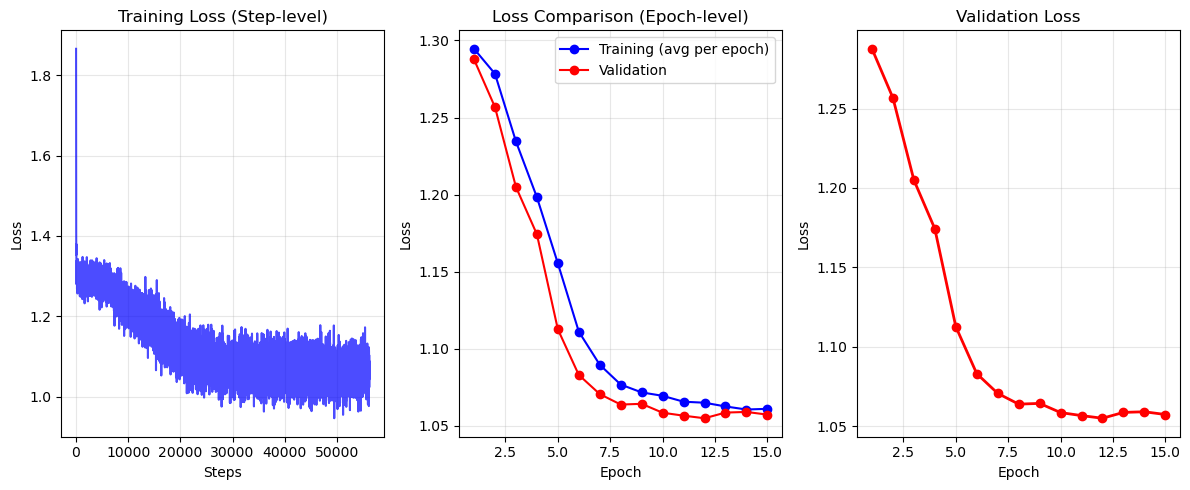

In [11]:
# Plot loss curves
logs = trainer.state.log_history
train_logs = [x for x in logs if 'loss' in x and 'eval_loss' not in x]
eval_logs = [x for x in logs if 'eval_loss' in x]

# Get step-level training loss
train_steps = [x['step'] for x in train_logs]
train_losses = [x['loss'] for x in train_logs]

# Get epoch-level validation loss
eval_epochs = [x['epoch'] for x in eval_logs]
eval_losses = [x['eval_loss'] for x in eval_logs]

# Calculate epoch-averaged training loss
epochs = list(range(1, int(max(eval_epochs)) + 1))
train_loss_per_epoch = []

for epoch in epochs:
    # Find training losses for this epoch
    epoch_start = (epoch - 1) * (len(train_dataset) // 16)  # steps per epoch
    epoch_end = epoch * (len(train_dataset) // 16)

    epoch_losses = [loss for step, loss in zip(train_steps, train_losses)
                   if epoch_start < step <= epoch_end]

    if epoch_losses:
        train_loss_per_epoch.append(np.mean(epoch_losses))
    else:
        train_loss_per_epoch.append(None)

plt.figure(figsize=(12, 5))

# Plot 1: Step-level training loss
plt.subplot(1, 3, 1)
plt.plot(train_steps, train_losses, 'b-', alpha=0.7)
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss (Step-level)')
plt.grid(True, alpha=0.3)

# Plot 2: Epoch-level comparison
plt.subplot(1, 3, 2)
plt.plot(epochs, train_loss_per_epoch, 'bo-', label='Training (avg per epoch)')
plt.plot(eval_epochs, eval_losses, 'ro-', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Comparison (Epoch-level)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Validation loss only
plt.subplot(1, 3, 3)
plt.plot(eval_epochs, eval_losses, 'ro-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
project_root = Path.cwd().parent
save_directory = project_root / "model" / "Tiger_baseline_100k_1e-4"

trainer.save_model(str(save_directory))

Running prediction on Validation set...


Total tokens for evaluation: 116906
Filtered out [CLS] tokens with ID: 6


/home/shishir-sunar/InsDelGLM/notebooks/../helpers/conf_matrix.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts_ordered, palette="viridis")


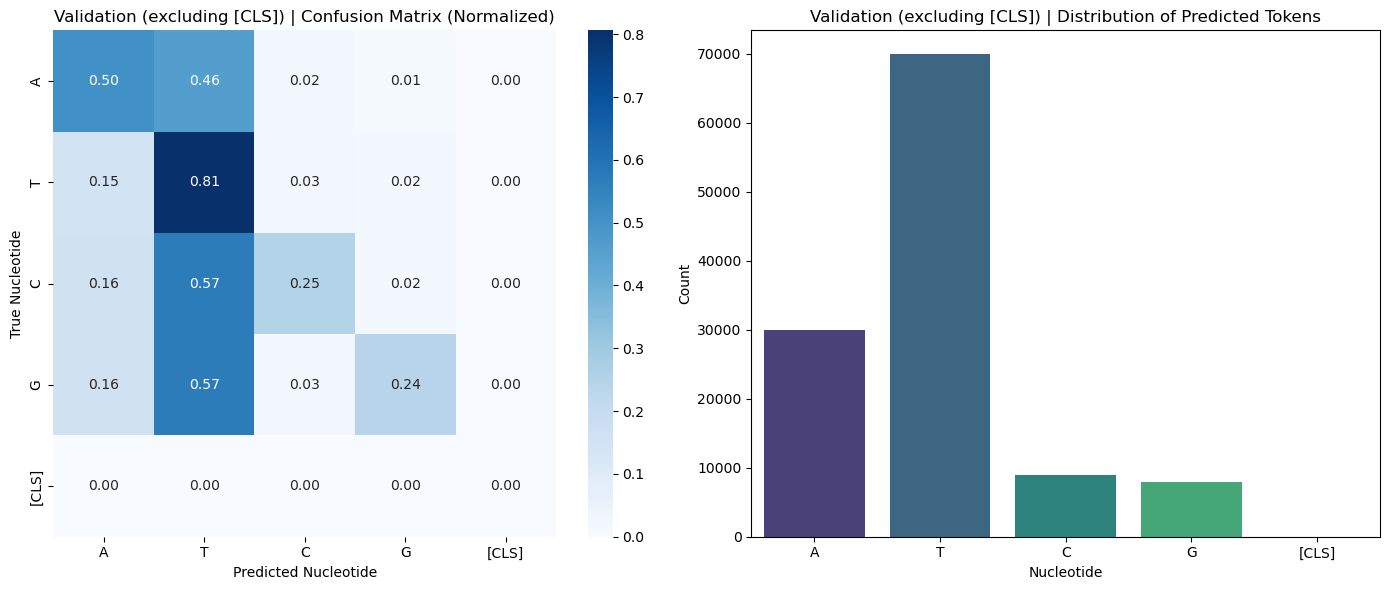

In [13]:
# Load the saved model
project_root = Path.cwd().parent
model_directory = project_root / "model" / "Tiger_baseline_100k_1e-4"

# Load the saved model using safetensors
from safetensors.torch import load_file

loaded_model = DNABertForMaskedLM(config)
state_dict = load_file(model_directory / "model.safetensors")
loaded_model.load_state_dict(state_dict)
loaded_model.to(device)
loaded_model.eval()

# Create evaluation arguments
eval_args = TrainingArguments(
    output_dir="../checkpoints/temp_eval",
    per_device_eval_batch_size=16,
    do_train=False,
    do_eval=True,
)

# Create a new trainer with the loaded model
eval_trainer = Trainer(
    model=loaded_model,
    args=eval_args,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
)

print("Running prediction on Validation set...")
output = eval_trainer.predict(eval_dataset)

logits = output.predictions
labels = output.label_ids

pred_ids_flat = np.argmax(logits, axis=-1).flatten()
labels_flat = labels.flatten()

# Filter out padding tokens (-100) and [CLS] token (ID 7)
mask = (labels_flat != -100) & (labels_flat != tokenizer.tokens_to_ids[tokenizer.cls_token])
true_ids_filtered = labels_flat[mask]
pred_ids_filtered = pred_ids_flat[mask]

print(f"Total tokens for evaluation: {len(true_ids_filtered)}")
print(f"Filtered out [CLS] tokens with ID: {tokenizer.tokens_to_ids[tokenizer.cls_token]}")

plot_evaluation_results(
    true_ids_filtered,
    pred_ids_filtered,
    tokenizer,
    dataset_name="Validation (excluding [CLS])"
)